# Modeling, Evaluation, Explainability & Trust

This notebook is a cleaned-up extension of the original `modeling.ipynb`.

It focuses on the following parts:
- **Model comparison** between an interpretable linear model and a nonlinear MLP
- **Evaluation beyond accuracy**
- **Explainability & trust**
- **Exports for Person 5's Streamlit map**

**Models used**
- **Model 1**: Linear Regression (interpretable baseline)
- **Model 2**: MLP Regressor (nonlinear model)

**Main outputs**
- saved evaluation tables and plots
- saved model files and model weights
- uncertainty estimates
- dashboard-ready CSV files


## Notebook roadmap

In order:
1. locate the data files
2. load and prepare the datasets
3. define the models and evaluation helpers
4. run temporal and spatial hold-out evaluation
5. compute change-specific metrics and stress tests
6. analyze where the model is wrong
7. create non-expert explanations and trust outputs
8. export files for the dashboard team

## 1. Setup and configuration

If automatic file discovery fails, only edit the two manual path variables in the next cell.

In [2]:
from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.base import clone
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

# ----- manual overrides: edit only if auto-discovery fails -----
MANUAL_FEATURES_DIR = None
MANUAL_TRAINING_DATA_DIR = None

# ----- general settings -----
PROJECT_ROOT = Path.cwd()
RANDOM_STATE = 42
SPATIAL_BLOCK_SIZE = 10
CHANGE_THRESHOLD = 1.0          # percentage points
NOISE_LEVELS = [0.00, 0.05, 0.10, 0.20, 0.30]
MISSING_LEVELS = [0.00, 0.10, 0.20, 0.30]
N_BOOT = 8                      # increase to 20 for a heavier final run if time allows

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "Modeling_Pipeline"
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
EXPORT_DIR = OUTPUT_DIR / "exports"
MODEL_DIR = OUTPUT_DIR / "models"
WEIGHT_DIR = MODEL_DIR / "weights"

for path in [OUTPUT_DIR, FIG_DIR, TABLE_DIR, EXPORT_DIR, MODEL_DIR, WEIGHT_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Output folder: {OUTPUT_DIR}")


Project root: /home/prabin/Documents/Assignments - UTN/ML/Data-Generation-Pipeline
Output folder: /home/prabin/Documents/Assignments - UTN/ML/Data-Generation-Pipeline/outputs/Modeling_Pipeline


## 2. Locate the required files

The notebook expects the same files from:
- 3 feature tables from the `Features/` folder
- 3 label tables from `data/training_data/.../grid_stats.csv`

The next cell searches for them automatically and prints what it finds.

In [3]:
def _clean_matches(paths):
    return sorted({p.resolve() for p in paths if '.ipynb_checkpoints' not in str(p)})


def find_single_file(filename, roots):
    matches = []
    for root in roots:
        if root is None or not root.exists():
            continue
        matches.extend(root.rglob(filename))
    matches = _clean_matches(matches)
    if not matches:
        raise FileNotFoundError(f"Could not find '{filename}'. Check your project folders or set a manual path.")
    if len(matches) > 1:
        print(f"[info] Multiple matches found for {filename}. Using: {matches[0]}")
    return matches[0]


def find_training_data_root(roots):
    # First try common direct locations.
    direct_candidates = [
        PROJECT_ROOT / 'data' / 'training_data',
        PROJECT_ROOT / 'data' / 'ml_tables',
        PROJECT_ROOT.parent / 'data' / 'training_data',
    ]
    for candidate in direct_candidates:
        if (candidate / 'Composition_prediction_in_3_years' / '2020' / 'grid_stats.csv').exists() and            (candidate / 'Composition_prediction_in_3_years' / '2021' / 'grid_stats.csv').exists() and            (candidate / 'Composition_diff_in_one_year' / 'grid_stats.csv').exists():
            return candidate.resolve()

    # Then search recursively.
    for root in roots:
        if root is None or not root.exists():
            continue
        for match in root.rglob('Composition_prediction_in_3_years'):
            candidate = match.parent
            if (candidate / 'Composition_prediction_in_3_years' / '2020' / 'grid_stats.csv').exists() and                (candidate / 'Composition_prediction_in_3_years' / '2021' / 'grid_stats.csv').exists() and                (candidate / 'Composition_diff_in_one_year' / 'grid_stats.csv').exists():
                return candidate.resolve()

    raise FileNotFoundError('Could not find the training_data root. Set MANUAL_TRAINING_DATA_DIR manually.')


search_roots = [PROJECT_ROOT, PROJECT_ROOT.parent]

if MANUAL_FEATURES_DIR is not None:
    FEATURES_DIR = Path(MANUAL_FEATURES_DIR).resolve()
else:
    FEATURES_DIR = find_single_file('features_clean_2020_renamed.csv', search_roots).parent

if MANUAL_TRAINING_DATA_DIR is not None:
    TRAINING_DATA_DIR = Path(MANUAL_TRAINING_DATA_DIR).resolve()
else:
    TRAINING_DATA_DIR = find_training_data_root(search_roots)

FEATURE_2020_PATH = FEATURES_DIR / 'features_clean_2020_renamed.csv'
FEATURE_2021_PATH = FEATURES_DIR / 'features_clean_2021_renamed.csv'
FEATURE_DIFF_PATH = FEATURES_DIR / 'features_clean_diff_renamed.csv'

TARGET_2020_PATH = TRAINING_DATA_DIR / 'Composition_prediction_in_3_years' / '2020' / 'grid_stats.csv'
TARGET_2021_PATH = TRAINING_DATA_DIR / 'Composition_prediction_in_3_years' / '2021' / 'grid_stats.csv'
TARGET_DIFF_PATH = TRAINING_DATA_DIR / 'Composition_diff_in_one_year' / 'grid_stats.csv'

for path in [FEATURE_2020_PATH, FEATURE_2021_PATH, FEATURE_DIFF_PATH,
             TARGET_2020_PATH, TARGET_2021_PATH, TARGET_DIFF_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}")

print('Features folder :', FEATURES_DIR)
print('Training data   :', TRAINING_DATA_DIR)
print('\nRequired files found successfully.')

Features folder : /home/prabin/Documents/Assignments - UTN/ML/Data-Generation-Pipeline/Features
Training data   : /home/prabin/Documents/Assignments - UTN/ML/Data-Generation-Pipeline/data/training_data

Required files found successfully.


## 3. Load the datasets

Instead of storing features and labels separately. Here we load both and merge them by `cell_id`.

We also make the column names consistent across years so the rest of the notebook stays readable.

In [4]:
def read_csv_checked(path):
    df = pd.read_csv(path)
    print(f"Loaded {path.name:35s} -> {df.shape}")
    return df


def strip_suffix(df, suffixes):
    df = df.copy()
    if isinstance(suffixes, str):
        suffixes = [suffixes]
    rename_map = {}
    for col in df.columns:
        new_col = col
        for suffix in suffixes:
            new_col = new_col.replace(f'_{suffix}', '')
        rename_map[col] = new_col
    return df.rename(columns=rename_map)


def ensure_target_columns(df, kind):
    df = df.copy()
    if kind == 'composition':
        if 'Other %' not in df.columns:
            df['Other %'] = 100 - df['Built-up %'] - df['Permanent water bodies %']
    elif kind == 'change':
        if 'delta Other %' not in df.columns:
            df['delta Other %'] = -(df['delta Built-up %'] + df['delta Permanent water bodies %'])
    return df


feat_2020 = strip_suffix(read_csv_checked(FEATURE_2020_PATH), '2020')
feat_2021 = strip_suffix(read_csv_checked(FEATURE_2021_PATH), '2021')
feat_diff = strip_suffix(read_csv_checked(FEATURE_DIFF_PATH), ['diff', 'clean'])

target_2020 = ensure_target_columns(read_csv_checked(TARGET_2020_PATH), 'composition')
target_2021 = ensure_target_columns(read_csv_checked(TARGET_2021_PATH), 'composition')
target_diff = ensure_target_columns(read_csv_checked(TARGET_DIFF_PATH), 'change')

coord_cols = [c for c in ['row', 'col', 'min_lon', 'min_lat', 'max_lon', 'max_lat'] if c in target_2020.columns]
target_cols_comp = ['cell_id'] + coord_cols + ['Built-up %', 'Permanent water bodies %', 'Other %']

coord_cols_diff = [c for c in ['row', 'col', 'min_lon', 'min_lat', 'max_lon', 'max_lat'] if c in target_diff.columns]
target_cols_diff = ['cell_id'] + coord_cols_diff + [
    'Built-up Baseline %', 'Permanent water bodies Baseline %',
    'delta Built-up %', 'delta Permanent water bodies %', 'delta Other %'
]


def merge_feature_target_tables(features, targets, target_cols):
    df = features.merge(targets[target_cols], on='cell_id', how='inner', suffixes=('', '_target'))
    for coord in ['row', 'col', 'min_lon', 'min_lat', 'max_lon', 'max_lat']:
        if coord not in df.columns and f'{coord}_target' in df.columns:
            df[coord] = df[f'{coord}_target']
    drop_cols = [c for c in df.columns if c.endswith('_target')]
    return df.drop(columns=drop_cols)


df_2020 = merge_feature_target_tables(feat_2020, target_2020, target_cols_comp)
df_2021 = merge_feature_target_tables(feat_2021, target_2021, target_cols_comp)
df_diff = merge_feature_target_tables(feat_diff, target_diff, target_cols_diff)

print('\nMerged tables:')
print('2020 composition:', df_2020.shape)
print('2021 composition:', df_2021.shape)
print('change table     :', df_diff.shape)

Loaded features_clean_2020_renamed.csv     -> (1600, 21)
Loaded features_clean_2021_renamed.csv     -> (1600, 21)
Loaded features_clean_diff_renamed.csv     -> (1600, 21)
Loaded grid_stats.csv                      -> (1600, 13)
Loaded grid_stats.csv                      -> (1600, 13)
Loaded grid_stats.csv                      -> (1600, 19)

Merged tables:
2020 composition: (1600, 28)
2021 composition: (1600, 28)
change table     : (1600, 30)


In [12]:
df.head()

,cell_id,row,col,R_mean,R_std,G_mean,G_std,B_mean,B_std,NDVI_1_mean,...,SWIR_3_std,min_lon,min_lat,max_lon,max_lat,Built-up Baseline %,Permanent water bodies Baseline %,delta Built-up %,delta Permanent water bodies %,delta Other %
0,0,0,0,94.441299,47.565605,80.120598,27.147528,51.921200,22.276628,158.164505,...,47.558830,10.944175,49.549852,10.953158,49.55568,9.30,0.13,0.41,-0.10,-0.31
1,1,0,1,101.252899,46.156986,81.111298,24.304808,53.610001,20.716566,181.781693,...,46.134609,10.953158,49.549852,10.962141,49.55568,10.54,0.81,0.48,0.45,-0.93
2,2,0,2,100.649498,43.026951,77.609901,25.206306,51.405701,20.964596,215.045395,...,43.030624,10.962141,49.549852,10.971125,49.55568,1.90,7.28,0.54,-0.78,0.24
3,3,0,3,54.661900,38.370583,51.835400,23.361496,30.210199,16.861359,92.312599,...,38.378223,10.971125,49.549852,10.980108,49.55568,0.00,5.48,0.00,-1.08,1.08
4,4,0,4,63.209400,28.062754,62.149502,17.174515,37.282101,17.287514,112.902000,...,28.061289,10.980108,49.549852,10.989091,49.55568,16.50,0.44,-0.14,0.35,-0.21


## 4. Quick sanity checks

Before modeling, let's scan a few important things:
- row counts
- duplicate keys
- missing values

In [7]:
summary_rows = []
for name, df in [('composition_2020', df_2020), ('composition_2021', df_2021), ('change', df_diff)]:
    summary_rows.append({
        'dataset': name,
        'rows': len(df),
        'columns': df.shape[1],
        'unique_cell_id': df['cell_id'].nunique(),
        'duplicate_cell_id': int(df['cell_id'].duplicated().sum()),
        'missing_values_total': int(df.isna().sum().sum()),
    })
summary_df = pd.DataFrame(summary_rows)
display(summary_df)
summary_df.to_csv(TABLE_DIR / 'dataset_summary.csv', index=False)

missing_df = pd.DataFrame({
    'column': df_diff.columns,
    'missing_count': df_diff.isna().sum().values,
    'missing_fraction': (df_diff.isna().mean().values).round(4),
}).sort_values(['missing_count', 'column'], ascending=[False, True])

display(missing_df.head(15))
missing_df.to_csv(TABLE_DIR / 'missing_values_summary.csv', index=False)


,dataset,rows,columns,unique_cell_id,duplicate_cell_id,missing_values_total
0,composition_2020,1600,28,1600,0,0
1,composition_2021,1600,28,1600,0,0
2,change,1600,30,1600,0,0


,column,missing_count,missing_fraction
7,B_mean,0,0.0
8,B_std,0,0.0
25,Built-up Baseline %,0,0.0
5,G_mean,0,0.0
6,G_std,0,0.0
9,NDVI_1_mean,0,0.0
10,NDVI_1_std,0,0.0
11,NDVI_2_mean,0,0.0
12,NDVI_2_std,0,0.0
13,NDVI_3_mean,0,0.0


## 5. Feature engineering

We keep the original spectral features, then add a few simple engineered features:
- cell center latitude and longitude
- NDVI-to-red ratio
- SWIR-to-green ratio

These are still tabular features, which stays within the assignment rules.

In [8]:
spectral_candidates = [
    'R_mean', 'R_std', 'G_mean', 'G_std', 'B_mean', 'B_std',
    'NDVI_1_mean', 'NDVI_1_std', 'NDVI_2_mean', 'NDVI_2_std', 'NDVI_3_mean', 'NDVI_3_std',
    'SWIR_1_mean', 'SWIR_1_std', 'SWIR_2_mean', 'SWIR_2_std', 'SWIR_3_mean', 'SWIR_3_std',
]


def engineer_features(df):
    df = df.copy()
    if {'min_lat', 'max_lat'}.issubset(df.columns):
        df['lat'] = (df['min_lat'] + df['max_lat']) / 2
    if {'min_lon', 'max_lon'}.issubset(df.columns):
        df['lon'] = (df['min_lon'] + df['max_lon']) / 2
    if {'NDVI_1_mean', 'R_mean'}.issubset(df.columns):
        df['NDVI_veg_ratio'] = df['NDVI_1_mean'] / (df['R_mean'] + 1e-6)
    if {'SWIR_1_mean', 'G_mean'}.issubset(df.columns):
        df['SWIR_moisture_ratio'] = df['SWIR_1_mean'] / (df['G_mean'] + 1e-6)
    return df


df_2020 = engineer_features(df_2020)
df_2021 = engineer_features(df_2021)
df_diff = engineer_features(df_diff)

available_spectral = [c for c in spectral_candidates if c in df_2020.columns]
SPECTRAL = [c for c in available_spectral if df_2020[c].std() > 1e-6]
DROPPED = sorted(set(available_spectral) - set(SPECTRAL))
if DROPPED:
    print('Dropped near-zero variance features:', DROPPED)

FEATURES_COMP = SPECTRAL + ['lat', 'lon', 'NDVI_veg_ratio', 'SWIR_moisture_ratio']
FEATURES_COMP = [c for c in FEATURES_COMP if c in df_2020.columns]
FEATURES_DIFF = FEATURES_COMP + ['Built-up Baseline %', 'Permanent water bodies Baseline %']
FEATURES_DIFF = [c for c in FEATURES_DIFF if c in df_diff.columns]

TARGETS_COMP = ['Built-up %', 'Permanent water bodies %']
TARGETS_DIFF = ['delta Built-up %', 'delta Permanent water bodies %']

feature_overview = pd.DataFrame({
    'composition_features': pd.Series(FEATURES_COMP),
    'change_features': pd.Series(FEATURES_DIFF),
})

display(feature_overview.head(15))
feature_overview.to_csv(TABLE_DIR / 'feature_overview.csv', index=False)
print(f'Composition features: {len(FEATURES_COMP)}')
print(f'Change features     : {len(FEATURES_DIFF)}')


Dropped near-zero variance features: ['NDVI_3_mean', 'NDVI_3_std']


,composition_features,change_features
0,R_mean,R_mean
1,R_std,R_std
2,G_mean,G_mean
3,G_std,G_std
4,B_mean,B_mean
5,B_std,B_std
6,NDVI_1_mean,NDVI_1_mean
7,NDVI_1_std,NDVI_1_std
8,NDVI_2_mean,NDVI_2_mean
9,NDVI_2_std,NDVI_2_std


Composition features: 20
Change features     : 22


## 6. Models and helper functions

We compare two models only:
- **Linear Regression** for interpretability
- **MLP** for nonlinear flexibility

The helper functions below keep the evaluation code short and readable.

In [14]:
def build_models(random_state=RANDOM_STATE):
    return {
        'Linear Regression': make_pipeline(
            StandardScaler(),
            LinearRegression(),
        ),
        'MLP': make_pipeline(
            StandardScaler(),
            MLPRegressor(
                hidden_layer_sizes=(64, 32),
                activation='relu',
                solver='adam',
                alpha=1e-4,
                learning_rate_init=1e-3,
                max_iter=400,
                early_stopping=True,
                validation_fraction=0.1,
                n_iter_no_change=20,
                random_state=random_state,
            ),
        ),
    }


def clip_composition(y_pred):
    y_pred = np.asarray(y_pred, dtype=float).copy()
    y_pred = np.clip(y_pred, 0.0, 100.0)
    row_sum = y_pred.sum(axis=1)
    over_mask = row_sum > 100.0
    if np.any(over_mask):
        y_pred[over_mask] = y_pred[over_mask] / row_sum[over_mask, None] * 100.0
    return y_pred


def clip_change(y_pred):
    return np.clip(np.asarray(y_pred, dtype=float), -100.0, 100.0)


def regression_metrics(y_true, y_pred, target_names):
    rows = []
    for idx, target in enumerate(target_names):
        rows.append({
            'Target': target,
            'MAE': mean_absolute_error(y_true[:, idx], y_pred[:, idx]),
            'RMSE': np.sqrt(mean_squared_error(y_true[:, idx], y_pred[:, idx])),
            'R2': r2_score(y_true[:, idx], y_pred[:, idx]),
        })
    return pd.DataFrame(rows)


def overall_mae(y_true, y_pred):
    return float(mean_absolute_error(y_true, y_pred))


def make_block_id(df, block_size=SPATIAL_BLOCK_SIZE):
    return (df['row'] // block_size).astype(str) + '_' + (df['col'] // block_size).astype(str)


def add_quadrant(df):
    df = df.copy()
    lat_mid = df['lat'].median()
    lon_mid = df['lon'].median()
    df['quadrant'] = np.where(
        (df['lat'] >= lat_mid) & (df['lon'] >= lon_mid), 'NE',
        np.where(
            (df['lat'] >= lat_mid) & (df['lon'] < lon_mid), 'NW',
            np.where((df['lat'] < lat_mid) & (df['lon'] < lon_mid), 'SW', 'SE')
        )
    )
    return df


def save_figure(fig, filename):
    fig.savefig(FIG_DIR / filename, bbox_inches='tight', dpi=160)

print('Model helpers are ready.')


Model helpers are ready.


In [15]:
def bootstrap_prediction_distribution(model_template, X_train, y_train, X_test, clip_fn, n_boot=N_BOOT, random_state=RANDOM_STATE):
    rng = np.random.RandomState(random_state)
    n = len(X_train)
    predictions = []

    for boot_idx in range(n_boot):
        sample_idx = rng.randint(0, n, size=n)
        model = clone(model_template)
        model.fit(X_train[sample_idx], y_train[sample_idx])
        y_pred = clip_fn(model.predict(X_test))
        predictions.append(y_pred)

    return np.stack(predictions, axis=0)


def run_temporal_holdout(train_df, test_df, feature_cols, target_cols, split_name, test_year, clip_fn):
    X_train = train_df[feature_cols].to_numpy(dtype=float)
    y_train = train_df[target_cols].to_numpy(dtype=float)
    X_test = test_df[feature_cols].to_numpy(dtype=float)
    y_test = test_df[target_cols].to_numpy(dtype=float)

    metric_frames = []
    prediction_frames = []
    fitted_models = {}

    for model_name, model_template in build_models().items():
        model = clone(model_template)
        model.fit(X_train, y_train)
        y_pred = clip_fn(model.predict(X_test))
        boot_dist = bootstrap_prediction_distribution(
            model_template, X_train, y_train, X_test, clip_fn,
            n_boot=N_BOOT, random_state=RANDOM_STATE + abs(hash((split_name, model_name))) % 10_000,
        )
        y_std = boot_dist.std(axis=0)

        metrics = regression_metrics(y_test, y_pred, target_cols)
        metrics['Model'] = model_name
        metrics['Split'] = split_name
        metrics['TestYear'] = test_year
        metric_frames.append(metrics)

        pred_df = test_df[['cell_id', 'row', 'col', 'min_lon', 'min_lat', 'max_lon', 'max_lat', 'lat', 'lon']].copy()
        pred_df['task'] = 'composition'
        pred_df['model'] = model_name
        pred_df['split'] = split_name
        pred_df['test_year'] = test_year
        pred_df['true_builtup'] = y_test[:, 0]
        pred_df['true_water'] = y_test[:, 1]
        pred_df['true_other'] = 100 - y_test[:, 0] - y_test[:, 1]
        pred_df['pred_builtup'] = y_pred[:, 0]
        pred_df['pred_water'] = y_pred[:, 1]
        pred_df['pred_other'] = 100 - y_pred[:, 0] - y_pred[:, 1]
        pred_df['unc_builtup'] = y_std[:, 0]
        pred_df['unc_water'] = y_std[:, 1]
        pred_df['unc_other'] = (100 - boot_dist[:, :, 0] - boot_dist[:, :, 1]).std(axis=0)
        pred_df['abs_error_builtup'] = np.abs(pred_df['true_builtup'] - pred_df['pred_builtup'])
        pred_df['abs_error_water'] = np.abs(pred_df['true_water'] - pred_df['pred_water'])
        prediction_frames.append(pred_df)

        fitted_models[(split_name, model_name)] = model

    return pd.concat(metric_frames, ignore_index=True), pd.concat(prediction_frames, ignore_index=True), fitted_models


def run_grouped_cv(df, feature_cols, target_cols, clip_fn):
    X = df[feature_cols].to_numpy(dtype=float)
    y = df[target_cols].to_numpy(dtype=float)
    groups = make_block_id(df).to_numpy()
    n_splits = min(4, pd.Series(groups).nunique())
    if n_splits < 2:
        raise ValueError('Need at least 2 spatial blocks for GroupKFold.')

    gkf = GroupKFold(n_splits=n_splits)
    fold_assignments = np.empty(len(df), dtype=int)

    metric_frames = []
    prediction_frames = []
    fitted_models = {}

    for model_name, model_template in build_models().items():
        y_pred_all = np.zeros_like(y, dtype=float)
        y_std_all = np.zeros_like(y, dtype=float)

        for fold_idx, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups), start=1):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            model = clone(model_template)
            model.fit(X_train, y_train)
            y_pred_fold = clip_fn(model.predict(X_test))
            y_pred_all[test_idx] = y_pred_fold
            fold_assignments[test_idx] = fold_idx

            boot_dist = bootstrap_prediction_distribution(
                model_template, X_train, y_train, X_test, clip_fn,
                n_boot=N_BOOT, random_state=RANDOM_STATE + 1000 * fold_idx + abs(hash(model_name)) % 10_000,
            )
            y_std_all[test_idx] = boot_dist.std(axis=0)

        metrics = regression_metrics(y, y_pred_all, target_cols)
        metrics['Model'] = model_name
        metrics['Split'] = 'spatial_group_kfold'
        metric_frames.append(metrics)

        pred_df = df[['cell_id', 'row', 'col', 'min_lon', 'min_lat', 'max_lon', 'max_lat', 'lat', 'lon']].copy()
        pred_df['task'] = 'change'
        pred_df['model'] = model_name
        pred_df['split'] = 'spatial_group_kfold'
        pred_df['fold_id'] = fold_assignments
        pred_df['true_delta_builtup'] = y[:, 0]
        pred_df['true_delta_water'] = y[:, 1]
        pred_df['true_delta_other'] = -(y[:, 0] + y[:, 1])
        pred_df['pred_delta_builtup'] = y_pred_all[:, 0]
        pred_df['pred_delta_water'] = y_pred_all[:, 1]
        pred_df['pred_delta_other'] = -(y_pred_all[:, 0] + y_pred_all[:, 1])
        pred_df['unc_delta_builtup'] = y_std_all[:, 0]
        pred_df['unc_delta_water'] = y_std_all[:, 1]
        pred_df['abs_error_delta_builtup'] = np.abs(pred_df['true_delta_builtup'] - pred_df['pred_delta_builtup'])
        pred_df['abs_error_delta_water'] = np.abs(pred_df['true_delta_water'] - pred_df['pred_delta_water'])
        prediction_frames.append(pred_df)

        fitted_models[model_name] = clone(model_template).fit(X, y)

    return pd.concat(metric_frames, ignore_index=True), pd.concat(prediction_frames, ignore_index=True), fitted_models


def add_change_flags(df, true_col, pred_col, threshold=CHANGE_THRESHOLD):
    df = df.copy()
    df['true_change_flag'] = (df[true_col].abs() >= threshold).astype(int)
    df['pred_change_flag'] = (df[pred_col].abs() >= threshold).astype(int)
    return df

print('Evaluation helpers are ready.')


Evaluation helpers are ready.


## 7. Temporal hold-out: land-cover composition

For composition prediction we use a **temporal hold-out**:
- train on 2020 and test on 2021
- train on 2021 and test on 2020

In [ ]:
comp_metrics_1, comp_preds_1, fitted_comp_f1 = run_temporal_holdout(
    train_df=df_2020,
    test_df=df_2021,
    feature_cols=FEATURES_COMP,
    target_cols=TARGETS_COMP,
    split_name='train_2020_test_2021',
    test_year=2021,
    clip_fn=clip_composition,
)

comp_metrics_2, comp_preds_2, fitted_comp_f2 = run_temporal_holdout(
    train_df=df_2021,
    test_df=df_2020,
    feature_cols=FEATURES_COMP,
    target_cols=TARGETS_COMP,
    split_name='train_2021_test_2020',
    test_year=2020,
    clip_fn=clip_composition,
)

composition_metrics = pd.concat([comp_metrics_1, comp_metrics_2], ignore_index=True)
composition_predictions = pd.concat([comp_preds_1, comp_preds_2], ignore_index=True)
composition_predictions = add_quadrant(composition_predictions)

composition_metrics.to_csv(TABLE_DIR / 'composition_temporal_metrics.csv', index=False)
composition_predictions.to_csv(EXPORT_DIR / 'composition_predictions_long.csv', index=False)

print('Saved composition metrics and out-of-sample predictions.')
display(composition_metrics.round(4))

Saved composition metrics and out-of-sample predictions.


,Target,MAE,RMSE,R2,Model,Split,TestYear
0,Built-up %,7.0875,11.1239,0.8077,Linear Regression,train_2020_test_2021,2021
1,Permanent water bodies %,0.7155,1.5405,0.6647,Linear Regression,train_2020_test_2021,2021
2,Built-up %,5.6631,9.1000,0.8713,MLP,train_2020_test_2021,2021
3,Permanent water bodies %,0.3198,0.7997,0.9097,MLP,train_2020_test_2021,2021
4,Built-up %,6.2549,8.7202,0.8749,Linear Regression,train_2021_test_2020,2020
5,Permanent water bodies %,0.7572,1.5533,0.6636,Linear Regression,train_2021_test_2020,2020
6,Built-up %,4.1663,6.5091,0.9303,MLP,train_2021_test_2020,2020
7,Permanent water bodies %,0.3661,0.8959,0.8881,MLP,train_2021_test_2020,2020


,Model,Target,MAE,RMSE,R2
0,Linear Regression,Built-up %,6.6712,9.9221,0.8413
1,Linear Regression,Permanent water bodies %,0.7364,1.5469,0.6642
2,MLP,Built-up %,4.9147,7.8046,0.9008
3,MLP,Permanent water bodies %,0.3430,0.8478,0.8989


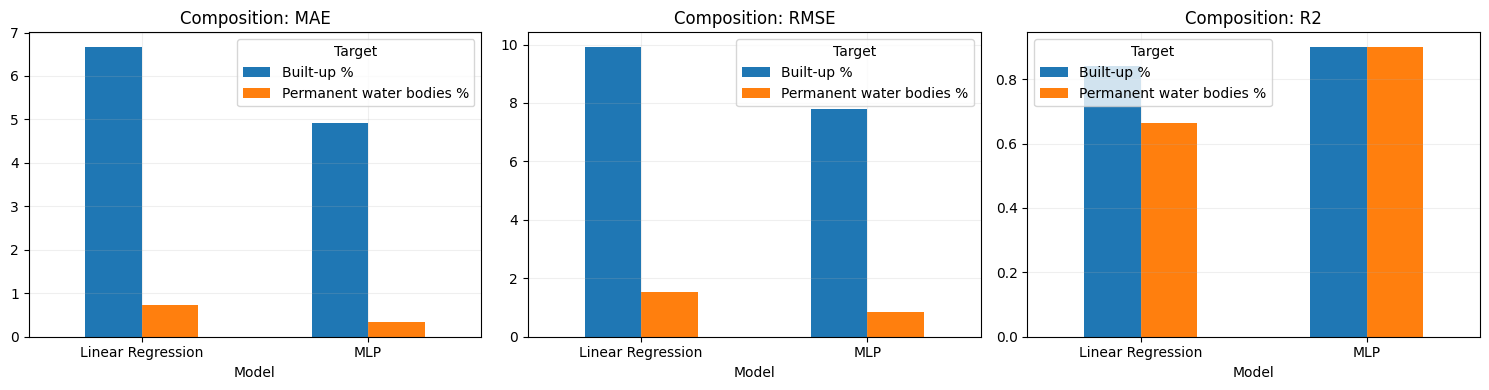

In [17]:
composition_summary = (
    composition_metrics
    .groupby(['Model', 'Target'])[['MAE', 'RMSE', 'R2']]
    .mean()
    .reset_index()
)

display(composition_summary.round(4))
composition_summary.to_csv(TABLE_DIR / 'composition_temporal_summary.csv', index=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ['MAE', 'RMSE', 'R2']):
    pivot = composition_summary.pivot(index='Model', columns='Target', values=metric)
    pivot.plot(kind='bar', ax=ax, rot=0)
    ax.set_title(f'Composition: {metric}')
    ax.grid(alpha=0.2)
plt.tight_layout()
save_figure(fig, 'composition_temporal_comparison.png')
plt.show()


## 8. Spatial hold-out: land-cover change

For change prediction we use **GroupKFold** on spatial blocks.
Cells inside the same coarse block stay in the same fold, which reduces spatial leakage.

This gives each cell an out-of-fold prediction while keeping the evaluation spatially honest.

In [18]:
change_metrics, change_predictions, fitted_change_models = run_grouped_cv(
    df=df_diff,
    feature_cols=FEATURES_DIFF,
    target_cols=TARGETS_DIFF,
    clip_fn=clip_change,
)

change_predictions = add_quadrant(change_predictions)
change_predictions.to_csv(EXPORT_DIR / 'change_predictions_long.csv', index=False)
change_metrics.to_csv(TABLE_DIR / 'change_spatial_metrics.csv', index=False)

print('Saved change metrics and out-of-fold predictions.')
display(change_metrics.round(4))


Saved change metrics and out-of-fold predictions.


,Target,MAE,RMSE,R2,Model,Split
0,delta Built-up %,0.7908,1.2867,0.1562,Linear Regression,spatial_group_kfold
1,delta Permanent water bodies %,0.1269,0.3829,-0.0502,Linear Regression,spatial_group_kfold
2,delta Built-up %,0.7583,1.2182,0.2436,MLP,spatial_group_kfold
3,delta Permanent water bodies %,0.1667,0.4158,-0.2383,MLP,spatial_group_kfold


,Model,Target,MAE,RMSE,R2
0,Linear Regression,delta Built-up %,0.7908,1.2867,0.1562
1,Linear Regression,delta Permanent water bodies %,0.1269,0.3829,-0.0502
2,MLP,delta Built-up %,0.7583,1.2182,0.2436
3,MLP,delta Permanent water bodies %,0.1667,0.4158,-0.2383


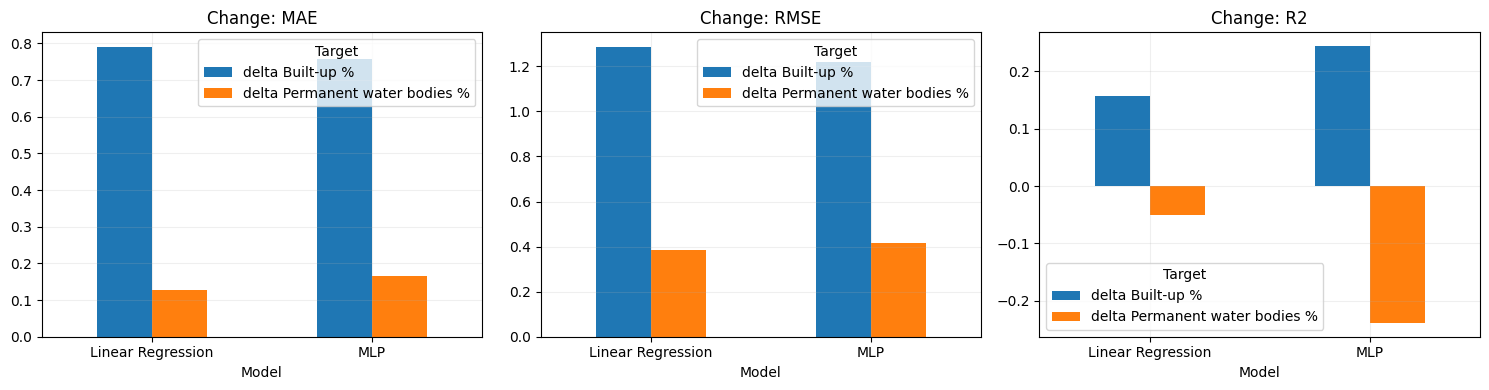

Best composition model: MLP
Best change model     : Linear Regression


In [19]:
change_summary = (
    change_metrics
    .groupby(['Model', 'Target'])[['MAE', 'RMSE', 'R2']]
    .mean()
    .reset_index()
)

display(change_summary.round(4))
change_summary.to_csv(TABLE_DIR / 'change_spatial_summary.csv', index=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ['MAE', 'RMSE', 'R2']):
    pivot = change_summary.pivot(index='Model', columns='Target', values=metric)
    pivot.plot(kind='bar', ax=ax, rot=0)
    ax.set_title(f'Change: {metric}')
    ax.grid(alpha=0.2)
plt.tight_layout()
save_figure(fig, 'change_spatial_comparison.png')
plt.show()

best_comp_model = composition_summary.groupby('Model')['MAE'].mean().idxmin()
best_change_model = change_summary.groupby('Model')['MAE'].mean().idxmin()
print('Best composition model:', best_comp_model)
print('Best change model     :', best_change_model)


## 9. Part D: change-specific metrics

Accuracy alone is not enough.
We add metrics that specifically answer:
- does the model hallucinate change where nothing changed?
- does it get the direction of real change right?

Threshold used here: **1 percentage point**.

In [20]:
def binary_change_metrics(y_true, y_pred, threshold=CHANGE_THRESHOLD):
    true_change = np.abs(y_true) >= threshold
    pred_change = np.abs(y_pred) >= threshold

    tp = np.sum(true_change & pred_change)
    tn = np.sum(~true_change & ~pred_change)
    fp = np.sum(~true_change & pred_change)
    fn = np.sum(true_change & ~pred_change)

    precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    false_change_rate = fp / (fp + tn) if (fp + tn) > 0 else np.nan

    changed_mask = true_change
    direction_accuracy = np.mean(np.sign(y_true[changed_mask]) == np.sign(y_pred[changed_mask])) if changed_mask.any() else np.nan

    return {
        'precision_change': precision,
        'recall_change': recall,
        'false_change_rate': false_change_rate,
        'direction_accuracy': direction_accuracy,
        'n_changed': int(true_change.sum()),
        'n_stable': int((~true_change).sum()),
    }


change_metric_rows = []
for model_name, group in change_predictions.groupby('model'):
    for true_col, pred_col, label in [
        ('true_delta_builtup', 'pred_delta_builtup', 'delta Built-up %'),
        ('true_delta_water', 'pred_delta_water', 'delta Permanent water bodies %'),
    ]:
        row = binary_change_metrics(group[true_col].to_numpy(), group[pred_col].to_numpy(), threshold=CHANGE_THRESHOLD)
        row['Model'] = model_name
        row['Target'] = label
        change_metric_rows.append(row)

change_specific_metrics = pd.DataFrame(change_metric_rows)
change_specific_metrics = change_specific_metrics[['Model', 'Target', 'precision_change', 'recall_change', 'false_change_rate', 'direction_accuracy', 'n_changed', 'n_stable']]

display(change_specific_metrics.round(4))
change_specific_metrics.to_csv(TABLE_DIR / 'change_specific_metrics.csv', index=False)


,Model,Target,precision_change,recall_change,false_change_rate,direction_accuracy,n_changed,n_stable
0,Linear Regression,delta Built-up %,0.6429,0.7076,0.1341,0.8378,407,1193
1,Linear Regression,delta Permanent water bodies %,NaN,0.0000,0.0000,0.5714,28,1572
2,MLP,delta Built-up %,0.6422,0.6658,0.1266,0.8256,407,1193
3,MLP,delta Permanent water bodies %,0.1250,0.0357,0.0045,0.6071,28,1572


## 10. Part D: stress test A - feature noise

We inject Gaussian noise into the **2021 temporal test set**.
This simulates sensor noise, residual cloud contamination, and imperfect feature extraction.

We report overall MAE after noise is added.

,Model,NoiseLevel,MAE
0,Linear Regression,0.00,3.9015
1,Linear Regression,0.05,17.9452
2,Linear Regression,0.10,21.4015
3,Linear Regression,0.20,25.2289
4,Linear Regression,0.30,27.8869
5,MLP,0.00,2.9914
6,MLP,0.05,3.0050
7,MLP,0.10,3.2153
8,MLP,0.20,3.5724
9,MLP,0.30,4.2068


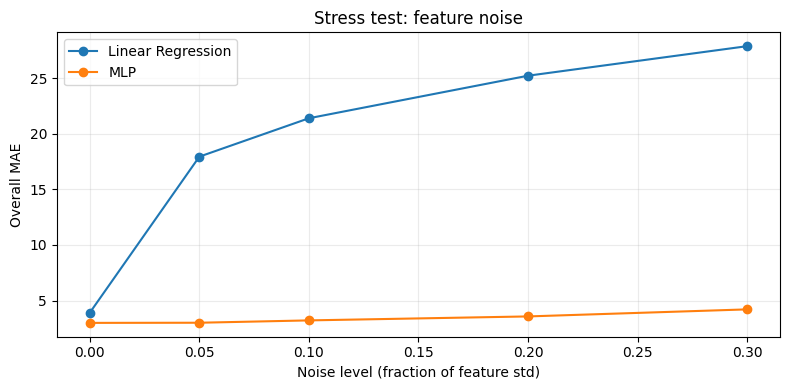

In [21]:
X_train_stress = df_2020[FEATURES_COMP].to_numpy(dtype=float)
y_train_stress = df_2020[TARGETS_COMP].to_numpy(dtype=float)
X_test_stress = df_2021[FEATURES_COMP].to_numpy(dtype=float)
y_test_stress = df_2021[TARGETS_COMP].to_numpy(dtype=float)

rng = np.random.RandomState(RANDOM_STATE)
feature_std = X_train_stress.std(axis=0)

noise_rows = []
for model_name, model_template in build_models().items():
    model = clone(model_template)
    model.fit(X_train_stress, y_train_stress)

    for noise_level in NOISE_LEVELS:
        X_noisy = X_test_stress + rng.normal(loc=0.0, scale=noise_level, size=X_test_stress.shape) * feature_std
        y_pred = clip_composition(model.predict(X_noisy))
        noise_rows.append({
            'Model': model_name,
            'NoiseLevel': noise_level,
            'MAE': overall_mae(y_test_stress, y_pred),
        })

noise_stress_df = pd.DataFrame(noise_rows)
display(noise_stress_df.round(4))
noise_stress_df.to_csv(TABLE_DIR / 'stress_test_noise.csv', index=False)

fig, ax = plt.subplots(figsize=(8, 4))
for model_name, group in noise_stress_df.groupby('Model'):
    ax.plot(group['NoiseLevel'], group['MAE'], marker='o', label=model_name)
ax.set_title('Stress test: feature noise')
ax.set_xlabel('Noise level (fraction of feature std)')
ax.set_ylabel('Overall MAE')
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
save_figure(fig, 'stress_test_noise.png')
plt.show()


## 11. Part D: stress test B - missing data simulation

We randomly remove part of the test-set features and then fill them with **training-set medians**.
This simulates missing bands, failed feature extraction, or masked observations.

Again, we report overall MAE.

,Model,MissingFraction,MAE
0,Linear Regression,0.0,3.9015
1,Linear Regression,0.1,15.3874
2,Linear Regression,0.2,21.2494
3,Linear Regression,0.3,24.1387
4,MLP,0.0,2.9914
5,MLP,0.1,3.7328
6,MLP,0.2,4.6267
7,MLP,0.3,5.2599


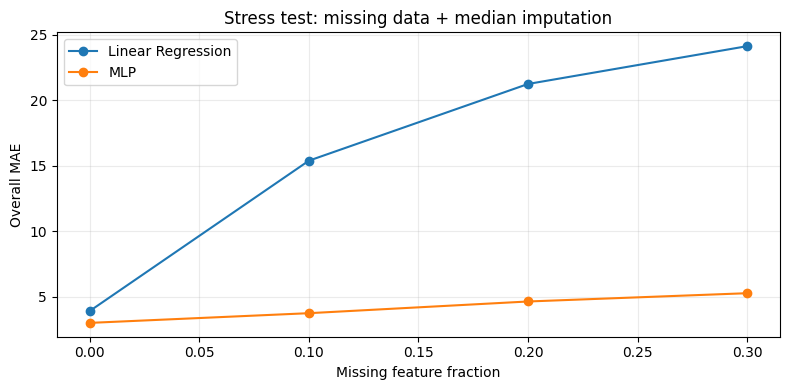

In [22]:
train_medians = np.median(X_train_stress, axis=0)
missing_rows = []

for model_name, model_template in build_models().items():
    model = clone(model_template)
    model.fit(X_train_stress, y_train_stress)

    for missing_fraction in MISSING_LEVELS:
        rng = np.random.RandomState(RANDOM_STATE + int(missing_fraction * 1000))
        X_missing = X_test_stress.copy()
        if missing_fraction > 0:
            mask = rng.rand(*X_missing.shape) < missing_fraction
            X_missing[mask] = np.nan
            nan_idx = np.where(np.isnan(X_missing))
            X_missing[nan_idx] = np.take(train_medians, nan_idx[1])
        y_pred = clip_composition(model.predict(X_missing))
        missing_rows.append({
            'Model': model_name,
            'MissingFraction': missing_fraction,
            'MAE': overall_mae(y_test_stress, y_pred),
        })

missing_stress_df = pd.DataFrame(missing_rows)
display(missing_stress_df.round(4))
missing_stress_df.to_csv(TABLE_DIR / 'stress_test_missing.csv', index=False)

fig, ax = plt.subplots(figsize=(8, 4))
for model_name, group in missing_stress_df.groupby('Model'):
    ax.plot(group['MissingFraction'], group['MAE'], marker='o', label=model_name)
ax.set_title('Stress test: missing data + median imputation')
ax.set_xlabel('Missing feature fraction')
ax.set_ylabel('Overall MAE')
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
save_figure(fig, 'stress_test_missing.png')
plt.show()


## 12. Insights:
(for report)

### 12.A. Where and why is the model wrong?


We use the **best change model** and check whether error is larger in places that are:
- on the spatial edge of the grid
- truly changing a lot
- highly uncertain

In [23]:
best_change_df = change_predictions.loc[change_predictions['model'] == best_change_model].copy()

row_min, row_max = best_change_df['row'].min(), best_change_df['row'].max()
col_min, col_max = best_change_df['col'].min(), best_change_df['col'].max()
edge_buffer = 3

best_change_df['edge_cell'] = (
    (best_change_df['row'] <= row_min + edge_buffer) |
    (best_change_df['row'] >= row_max - edge_buffer) |
    (best_change_df['col'] <= col_min + edge_buffer) |
    (best_change_df['col'] >= col_max - edge_buffer)
)

best_change_df['high_true_change'] = best_change_df['true_delta_builtup'].abs() >= CHANGE_THRESHOLD
best_change_df['high_uncertainty'] = best_change_df['unc_delta_builtup'] >= best_change_df['unc_delta_builtup'].quantile(0.75)

where_wrong_rows = []
for label, mask in [
    ('edge cells', best_change_df['edge_cell']),
    ('interior cells', ~best_change_df['edge_cell']),
    ('high true change', best_change_df['high_true_change']),
    ('stable cells', ~best_change_df['high_true_change']),
    ('high uncertainty', best_change_df['high_uncertainty']),
    ('lower uncertainty', ~best_change_df['high_uncertainty']),
]:
    subset = best_change_df.loc[mask]
    where_wrong_rows.append({
        'group': label,
        'n_cells': len(subset),
        'mean_abs_error_delta_builtup': subset['abs_error_delta_builtup'].mean(),
        'mean_abs_error_delta_water': subset['abs_error_delta_water'].mean(),
        'mean_unc_delta_builtup': subset['unc_delta_builtup'].mean(),
    })

where_wrong_df = pd.DataFrame(where_wrong_rows)
display(where_wrong_df.round(4))
where_wrong_df.to_csv(TABLE_DIR / 'where_why_model_is_wrong.csv', index=False)

quadrant_error_summary = (
    best_change_df
    .groupby('quadrant')[['pred_delta_builtup', 'abs_error_delta_builtup', 'unc_delta_builtup']]
    .mean()
    .reset_index()
    .sort_values('pred_delta_builtup', ascending=False)
)

display(quadrant_error_summary.round(4))
quadrant_error_summary.to_csv(TABLE_DIR / 'quadrant_change_summary.csv', index=False)

worst_cells = best_change_df.nlargest(25, 'abs_error_delta_builtup')[[
    'cell_id', 'row', 'col', 'lat', 'lon', 'quadrant',
    'true_delta_builtup', 'pred_delta_builtup', 'abs_error_delta_builtup', 'unc_delta_builtup'
]].copy()
worst_cells.to_csv(EXPORT_DIR / 'worst_change_cells.csv', index=False)

display(worst_cells.head(10).round(4))


,group,n_cells,mean_abs_error_delta_builtup,mean_abs_error_delta_water,mean_unc_delta_builtup
0,edge cells,576,0.6853,0.1354,0.1923
1,interior cells,1024,0.8501,0.1221,0.1777
2,high true change,407,1.4886,0.1676,0.1933
3,stable cells,1193,0.5527,0.1130,0.1794
4,high uncertainty,400,1.1232,0.1866,0.3349
5,lower uncertainty,1200,0.6800,0.1070,0.1323


,quadrant,pred_delta_builtup,abs_error_delta_builtup,unc_delta_builtup
1,NW,0.8920,0.9150,0.1670
3,SW,0.6367,0.7952,0.1922
0,NE,0.0890,0.5328,0.1465
2,SE,-0.0698,0.9201,0.2261


,cell_id,row,col,lat,lon,quadrant,true_delta_builtup,pred_delta_builtup,abs_error_delta_builtup,unc_delta_builtup
415,415,10,15,49.4945,11.0834,NW,-13.62,0.4849,14.1049,0.1804
942,942,23,22,49.4185,11.1463,SE,10.02,-0.9189,10.9389,0.3241
488,488,12,8,49.4828,11.0205,NW,8.68,0.2622,8.4178,0.1426
1068,1068,26,28,49.4010,11.2002,SE,4.85,-2.3043,7.1543,0.4670
1489,1489,37,9,49.3367,11.0295,SW,8.11,2.0245,6.0855,0.2716
366,366,9,6,49.5003,11.0026,NW,6.35,0.7602,5.5898,0.2102
888,888,22,8,49.4244,11.0205,SW,7.46,1.9231,5.5369,0.1523
529,529,13,9,49.4769,11.0295,NW,6.43,1.0460,5.3840,0.0847
1143,1143,28,23,49.3893,11.1553,SE,0.11,-5.2341,5.3441,1.7805
708,708,17,28,49.4536,11.2002,NE,0.00,-5.3261,5.3261,1.4109


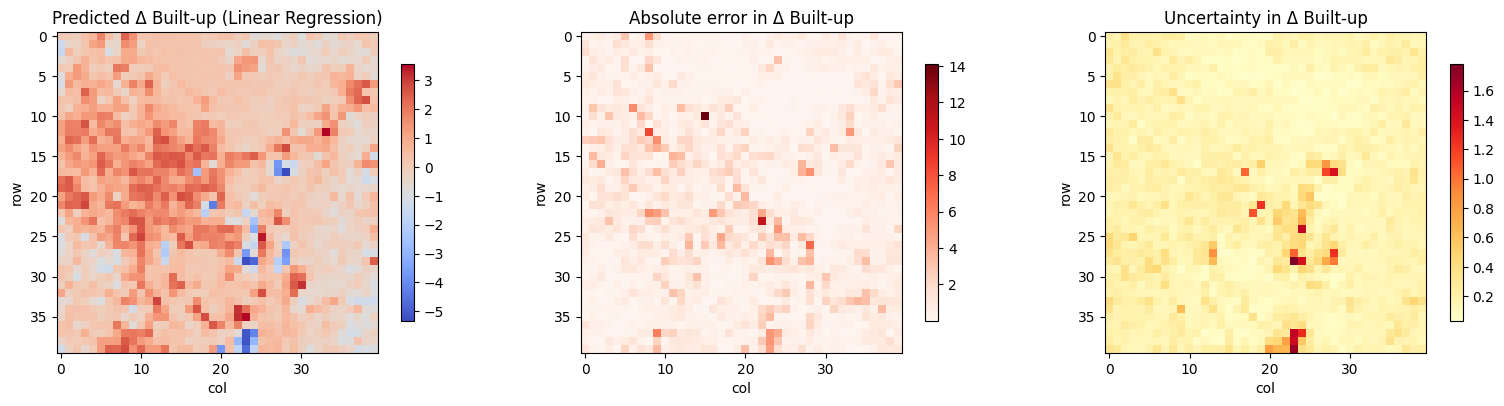

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

pivot_pred = best_change_df.pivot(index='row', columns='col', values='pred_delta_builtup')
pivot_err = best_change_df.pivot(index='row', columns='col', values='abs_error_delta_builtup')
pivot_unc = best_change_df.pivot(index='row', columns='col', values='unc_delta_builtup')

im0 = axes[0].imshow(pivot_pred, cmap='coolwarm')
axes[0].set_title(f'Predicted Δ Built-up ({best_change_model})')
plt.colorbar(im0, ax=axes[0], shrink=0.8)

im1 = axes[1].imshow(pivot_err, cmap='Reds')
axes[1].set_title('Absolute error in Δ Built-up')
plt.colorbar(im1, ax=axes[1], shrink=0.8)

im2 = axes[2].imshow(pivot_unc, cmap='YlOrRd')
axes[2].set_title('Uncertainty in Δ Built-up')
plt.colorbar(im2, ax=axes[2], shrink=0.8)

for ax in axes:
    ax.set_xlabel('col')
    ax.set_ylabel('row')

plt.tight_layout()
save_figure(fig, 'change_prediction_error_uncertainty_maps.png')
plt.show()


### 12.B Explainability and Trust

Three simple answers required:
- **what changed?**
- **where did it change?**
- **how confident is the model?**

We also add one explanation that is useful and one that would be misleading.

In [25]:
# Fit final models on all available rows so we can save weights and build explanations.
final_models_comp = {}
for model_name, template in build_models().items():
    final_models_comp[model_name] = clone(template).fit(
        pd.concat([df_2020, df_2021], ignore_index=True)[FEATURES_COMP].to_numpy(dtype=float),
        pd.concat([df_2020, df_2021], ignore_index=True)[TARGETS_COMP].to_numpy(dtype=float),
    )

final_models_change = {}
for model_name, template in build_models().items():
    final_models_change[model_name] = clone(template).fit(
        df_diff[FEATURES_DIFF].to_numpy(dtype=float),
        df_diff[TARGETS_DIFF].to_numpy(dtype=float),
    )

print('Final models trained for explanation and export.')


Final models trained for explanation and export.


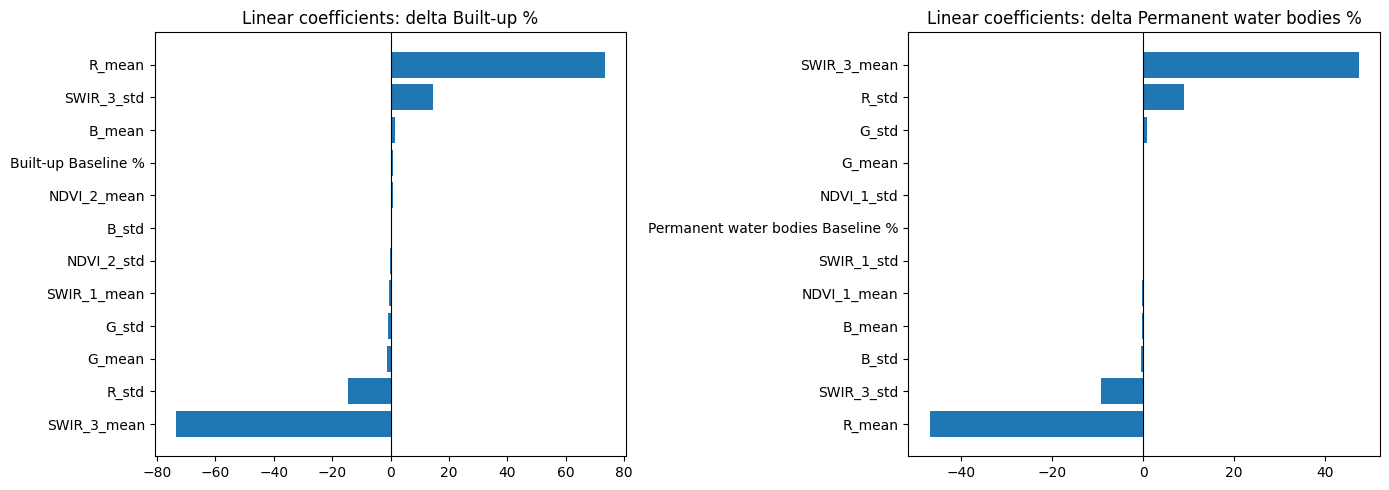

,feature,mae_increase
20,Built-up Baseline %,0.1176
8,NDVI_2_mean,0.0814
10,SWIR_1_mean,0.0772
7,NDVI_1_std,0.0673
18,NDVI_veg_ratio,0.0479
6,NDVI_1_mean,0.0461
14,SWIR_3_mean,0.0446
9,NDVI_2_std,0.0427
17,lon,0.0365
0,R_mean,0.0362


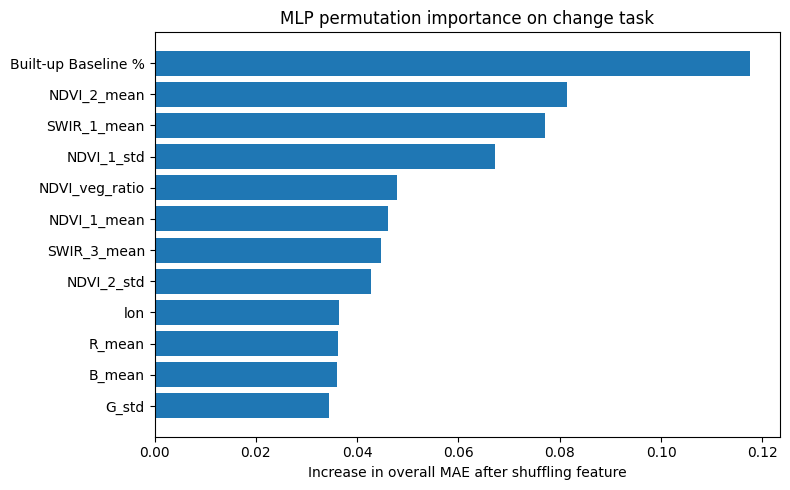

In [26]:
# ----- Linear Regression coefficients (helpful for interpretation) -----
linear_change_model = final_models_change['Linear Regression']
linear_scaler = linear_change_model.named_steps['standardscaler']
linear_reg = linear_change_model.named_steps['linearregression']
linear_coef = pd.DataFrame(
    linear_reg.coef_.T,
    index=FEATURES_DIFF,
    columns=TARGETS_DIFF,
).reset_index().rename(columns={'index': 'feature'})
linear_coef.to_csv(WEIGHT_DIR / 'linear_change_coefficients.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, target in zip(axes, TARGETS_DIFF):
    sorted_df = linear_coef[['feature', target]].copy()
    sorted_df['abs_coef'] = sorted_df[target].abs()
    sorted_df = sorted_df.sort_values('abs_coef', ascending=False).head(12).sort_values(target)
    ax.barh(sorted_df['feature'], sorted_df[target])
    ax.set_title(f'Linear coefficients: {target}')
    ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
save_figure(fig, 'linear_change_coefficients.png')
plt.show()

# ----- MLP permutation importance on the change task -----
mlp_change_model = final_models_change['MLP']
X_perm = df_diff[FEATURES_DIFF].to_numpy(dtype=float)
y_perm = df_diff[TARGETS_DIFF].to_numpy(dtype=float)
base_mae = overall_mae(y_perm, clip_change(mlp_change_model.predict(X_perm)))

perm_rows = []
rng = np.random.RandomState(RANDOM_STATE)
for feature_idx, feature_name in enumerate(FEATURES_DIFF):
    X_shuffled = X_perm.copy()
    rng.shuffle(X_shuffled[:, feature_idx])
    shuffled_mae = overall_mae(y_perm, clip_change(mlp_change_model.predict(X_shuffled)))
    perm_rows.append({
        'feature': feature_name,
        'mae_increase': shuffled_mae - base_mae,
    })

mlp_perm_importance = pd.DataFrame(perm_rows).sort_values('mae_increase', ascending=False)
mlp_perm_importance.to_csv(TABLE_DIR / 'mlp_change_permutation_importance.csv', index=False)

display(mlp_perm_importance.head(12).round(4))

fig, ax = plt.subplots(figsize=(8, 5))
top_perm = mlp_perm_importance.head(12).sort_values('mae_increase')
ax.barh(top_perm['feature'], top_perm['mae_increase'])
ax.set_title('MLP permutation importance on change task')
ax.set_xlabel('Increase in overall MAE after shuffling feature')
plt.tight_layout()
save_figure(fig, 'mlp_change_permutation_importance.png')
plt.show()


#### 12.C. Helpful explanation vs misleading explanation:

A good explanation helps a non-expert understand a prediction.
A bad explanation sounds confident but over-claims what the model actually knows.

The next cell creates both examples and saves them for the report and the app.

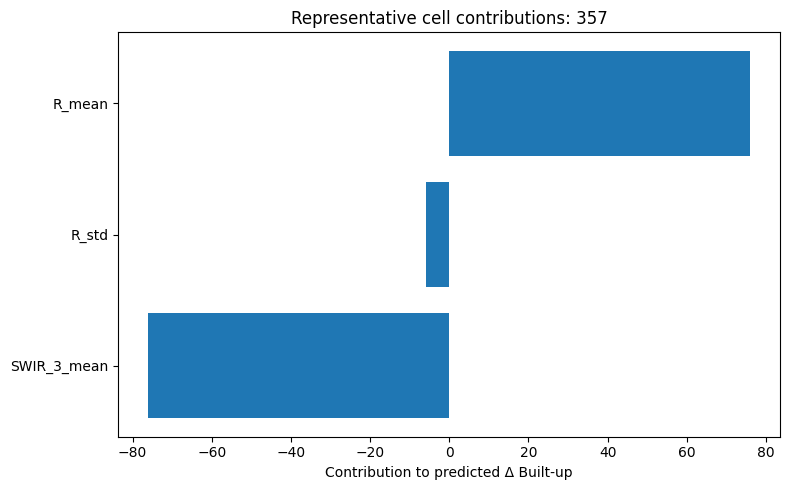

### Helpful explanation

Helpful explanation for cell 357: the linear model predicts an increase in built-up area mainly because SWIR_3_mean, R_mean, and R_std have the largest contributions to the predicted change. This is useful because it tells us which measured signals inside the feature pipeline are driving the prediction, not just the final number.

### Misleading explanation

Misleading explanation: 'This cell is changing because it is located farther east or north.' That sounds plausible because latitude and longitude can become important predictive features, but it is still a bad causal explanation. Coordinates are spatial proxies. They help the model locate repeating patterns, but they do not physically cause urban growth. Treating a location feature as a cause would overstate what the model has learned.

In [27]:
# Pick one representative cell: strong predicted built-up increase with below-median uncertainty.
representative_candidates = best_change_df[
    (best_change_df['pred_delta_builtup'] >= best_change_df['pred_delta_builtup'].quantile(0.90)) &
    (best_change_df['unc_delta_builtup'] <= best_change_df['unc_delta_builtup'].median())
].copy()
if representative_candidates.empty:
    representative_candidates = best_change_df.nlargest(20, 'pred_delta_builtup').copy()

representative_cell = representative_candidates.iloc[0]
cell_id_for_explanation = representative_cell['cell_id']

# Linear-model feature contributions for that cell.
source_row = df_diff.loc[df_diff['cell_id'] == cell_id_for_explanation].iloc[0]
x_cell = source_row[FEATURES_DIFF].to_numpy(dtype=float).reshape(1, -1)
x_cell_scaled = linear_scaler.transform(x_cell)
contrib = x_cell_scaled[0] * linear_reg.coef_[0]   # target 0 = delta Built-up %
contrib_df = pd.DataFrame({
    'feature': FEATURES_DIFF,
    'contribution_to_delta_builtup': contrib,
})
contrib_df['abs_contribution'] = contrib_df['contribution_to_delta_builtup'].abs()
contrib_df = contrib_df.sort_values('abs_contribution', ascending=False)
contrib_df.to_csv(TABLE_DIR / 'representative_cell_contributions.csv', index=False)

top3 = contrib_df.head(3)
helpful_explanation = (
    f"Helpful explanation for cell {cell_id_for_explanation}: the linear model predicts an increase in built-up area "
    f"mainly because {top3.iloc[0]['feature']}, {top3.iloc[1]['feature']}, and {top3.iloc[2]['feature']} "
    f"have the largest contributions to the predicted change. This is useful because it tells us which measured signals "
    f"inside the feature pipeline are driving the prediction, not just the final number."
)

misleading_explanation = (
    "Misleading explanation: 'This cell is changing because it is located farther east or north.' "
    "That sounds plausible because latitude and longitude can become important predictive features, but it is still a bad causal explanation. "
    "Coordinates are spatial proxies. They help the model locate repeating patterns, but they do not physically cause urban growth. "
    "Treating a location feature as a cause would overstate what the model has learned."
)

explanation_examples = pd.DataFrame([
    {'type': 'helpful', 'text': helpful_explanation},
    {'type': 'misleading', 'text': misleading_explanation},
])
explanation_examples.to_csv(EXPORT_DIR / 'explanation_examples.csv', index=False)

fig, ax = plt.subplots(figsize=(8, 5))
plot_df = top3.sort_values('contribution_to_delta_builtup')
ax.barh(plot_df['feature'], plot_df['contribution_to_delta_builtup'])
ax.set_title(f'Representative cell contributions: {cell_id_for_explanation}')
ax.set_xlabel('Contribution to predicted Δ Built-up')
plt.tight_layout()
save_figure(fig, 'representative_cell_contributions.png')
plt.show()

display(Markdown('### Helpful explanation'))
display(Markdown(helpful_explanation))
display(Markdown('### Misleading explanation'))
display(Markdown(misleading_explanation))


In [28]:
# Non-expert summary: what changed, where, and how confident are we?
summary_df = best_change_df.copy()
increase_mask = summary_df['pred_delta_builtup'] >= CHANGE_THRESHOLD
decrease_mask = summary_df['pred_delta_builtup'] <= -CHANGE_THRESHOLD
stable_mask = ~(increase_mask | decrease_mask)

quadrant_change = (
    summary_df.groupby('quadrant')[['pred_delta_builtup', 'unc_delta_builtup']]
    .mean()
    .sort_values('pred_delta_builtup', ascending=False)
)

top_quadrant = quadrant_change.index[0]
mean_unc = summary_df['unc_delta_builtup'].mean()
low_uncertainty_threshold = summary_df['unc_delta_builtup'].quantile(0.50)
confident_changed_cells = (increase_mask & (summary_df['unc_delta_builtup'] <= low_uncertainty_threshold)).sum()

non_expert_rows = [
    {
        'question': 'What changed?',
        'answer': f"{int(increase_mask.sum())} cells show predicted built-up increase, {int(decrease_mask.sum())} show decrease, and {int(stable_mask.sum())} stay within ±{CHANGE_THRESHOLD:.1f} percentage points.",
    },
    {
        'question': 'Where did it change?',
        'answer': f"The strongest average built-up increase appears in the {top_quadrant} quadrant of the study area.",
    },
    {
        'question': 'How confident is the model?',
        'answer': f"Average uncertainty in predicted built-up change is {mean_unc:.2f} percentage points. {int(confident_changed_cells)} of the increase cells are below the median uncertainty level.",
    },
]

non_expert_summary = pd.DataFrame(non_expert_rows)
non_expert_summary.to_csv(EXPORT_DIR / 'non_expert_summary.csv', index=False)
display(non_expert_summary)


,question,answer
0,What changed?,"382 cells show predicted built-up increase, 66..."
1,Where did it change?,The strongest average built-up increase appear...
2,How confident is the model?,Average uncertainty in predicted built-up chan...


## 15. Exports for Person 5

We export three dashboard-friendly files:
- **composition_dashboard.csv** for map layers of yearly land-cover predictions
- **change_dashboard.csv** for change layers, uncertainty, and error overlays
- **cell_explanations_dashboard.csv** for tooltip text in Streamlit

In [29]:
# Composition export: one row per cell, year, and model.
composition_dashboard = composition_predictions[[
    'cell_id', 'row', 'col', 'min_lon', 'min_lat', 'max_lon', 'max_lat', 'lat', 'lon',
    'quadrant', 'model', 'split', 'test_year',
    'true_builtup', 'true_water', 'true_other',
    'pred_builtup', 'pred_water', 'pred_other',
    'unc_builtup', 'unc_water', 'unc_other',
    'abs_error_builtup', 'abs_error_water'
]].copy()
composition_dashboard.rename(columns={'test_year': 'year'}, inplace=True)
composition_dashboard.to_csv(EXPORT_DIR / 'composition_dashboard.csv', index=False)

# Change export: one row per cell and model.
change_dashboard = best_change_df[[
    'cell_id', 'row', 'col', 'min_lon', 'min_lat', 'max_lon', 'max_lat', 'lat', 'lon',
    'quadrant', 'model', 'split', 'fold_id',
    'true_delta_builtup', 'true_delta_water', 'true_delta_other',
    'pred_delta_builtup', 'pred_delta_water', 'pred_delta_other',
    'unc_delta_builtup', 'unc_delta_water',
    'abs_error_delta_builtup', 'abs_error_delta_water'
]].copy()
change_dashboard['true_change_flag'] = (change_dashboard['true_delta_builtup'].abs() >= CHANGE_THRESHOLD).astype(int)
change_dashboard['pred_change_flag'] = (change_dashboard['pred_delta_builtup'].abs() >= CHANGE_THRESHOLD).astype(int)
change_dashboard['confidence_label'] = pd.cut(
    change_dashboard['unc_delta_builtup'],
    bins=[-np.inf,
          change_dashboard['unc_delta_builtup'].quantile(0.33),
          change_dashboard['unc_delta_builtup'].quantile(0.66),
          np.inf],
    labels=['high', 'medium', 'low'],
)
change_dashboard.to_csv(EXPORT_DIR / 'change_dashboard.csv', index=False)

# Text export for tooltips.
cell_explanations = change_dashboard[['cell_id', 'model', 'pred_delta_builtup', 'unc_delta_builtup', 'confidence_label']].copy()
cell_explanations['short_explanation'] = np.where(
    cell_explanations['pred_delta_builtup'] >= CHANGE_THRESHOLD,
    'Predicted increase in built-up land.',
    np.where(
        cell_explanations['pred_delta_builtup'] <= -CHANGE_THRESHOLD,
        'Predicted decrease in built-up land.',
        'No strong built-up change predicted.'
    )
)
cell_explanations['confidence_text'] = 'Confidence: ' + cell_explanations['confidence_label'].astype(str)
cell_explanations['limitation_text'] = 'Less reliable near boundaries, noisy cells, or cells with higher uncertainty.'
cell_explanations.to_csv(EXPORT_DIR / 'cell_explanations_dashboard.csv', index=False)

print('Saved dashboard files:')
for filename in ['composition_dashboard.csv', 'change_dashboard.csv', 'cell_explanations_dashboard.csv']:
    print(' -', EXPORT_DIR / filename)


Saved dashboard files:
 - /home/prabin/Documents/Assignments - UTN/ML/Data-Generation-Pipeline/outputs/Modeling_Pipeline/exports/composition_dashboard.csv
 - /home/prabin/Documents/Assignments - UTN/ML/Data-Generation-Pipeline/outputs/Modeling_Pipeline/exports/change_dashboard.csv
 - /home/prabin/Documents/Assignments - UTN/ML/Data-Generation-Pipeline/outputs/Modeling_Pipeline/exports/cell_explanations_dashboard.csv


## 16. Save trained models and weights

This final cell saves:
- fitted model files
- linear coefficients
- MLP weights

In [30]:
# Save final models.
for model_name, model in final_models_comp.items():
    filename = MODEL_DIR / f"composition_{model_name.lower().replace(' ', '_')}.joblib"
    joblib.dump(model, filename)

for model_name, model in final_models_change.items():
    filename = MODEL_DIR / f"change_{model_name.lower().replace(' ', '_')}.joblib"
    joblib.dump(model, filename)

# Save MLP weights in a simple NumPy format.
for task_name, model_dict in [('composition', final_models_comp), ('change', final_models_change)]:
    mlp_model = model_dict['MLP'].named_steps['mlpregressor']
    np.savez(
        WEIGHT_DIR / f'{task_name}_mlp_weights.npz',
        **{f'coef_{i}': arr for i, arr in enumerate(mlp_model.coefs_)},
        **{f'intercept_{i}': arr for i, arr in enumerate(mlp_model.intercepts_)},
    )

run_manifest = {
    'project_root': str(PROJECT_ROOT),
    'features_dir': str(FEATURES_DIR),
    'training_data_dir': str(TRAINING_DATA_DIR),
    'output_dir': str(OUTPUT_DIR),
    'best_composition_model': best_comp_model,
    'best_change_model': best_change_model,
    'change_threshold': CHANGE_THRESHOLD,
    'n_boot': N_BOOT,
}
with open(OUTPUT_DIR / 'run_manifest.json', 'w', encoding='utf-8') as f:
    json.dump(run_manifest, f, indent=2)

print('Model files and weights saved.')
print('Run manifest saved to:', OUTPUT_DIR / 'run_manifest.json')


Model files and weights saved.
Run manifest saved to: /home/prabin/Documents/Assignments - UTN/ML/Data-Generation-Pipeline/outputs/Modeling_Pipeline/run_manifest.json
